In [2]:
import numpy as np
import matplotlib.pyplot as plt
import measurments
from tqdm import tqdm

In [3]:
sims = {
    "comp-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach0.5-comp0.1"),
    "mix-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach0.5-mix"),
    "sol-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach0.5-sol"),
    "sol": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5"),
    "mix": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-comp"),
    "comp": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-comp0.1")
}

In [16]:
results = {sim_name: dict() for sim_name in sims}

for sim_name in results:
    results[sim_name]["mach_rms"] = np.zeros(50)
    results[sim_name]["dens_var"] = np.zeros(50)
    results[sim_name]["mean_dens"] = np.zeros(50)
    results[sim_name]["b1"] = np.zeros(50)
    results[sim_name]["b2"] = np.zeros(50)


for sim_name, sim in sims.items():
    for snap in tqdm(range(350, 360), desc=f"Simulation: {sim_name}"):
        i = snap - 350
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum(data["Velocities"]**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols) - mean_dens**2)
        b1 = (1/mach_rms) * dens_var/mean_dens
        results[sim_name]["mach_rms"][i] = mach_rms
        results[sim_name]["dens_var"][i] = dens_var
        results[sim_name]["mean_dens"][i] = mean_dens
        results[sim_name]["b1"][i] = b1

        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(128, 128, 128))
        field_k = np.fft.fftn(grid_velocites, axes=(0, 1, 2))
        kx = np.fft.fftfreq(128) * 128
        ky = np.fft.fftfreq(128) * 128
        kz = np.fft.fftfreq(128) * 128
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
        K = np.stack((KX, KY, KZ), axis=-1)

        k_squared = np.sum(K**2, axis=-1, keepdims=True)
        with np.errstate(divide='ignore', invalid='ignore'):
            k_unit = np.divide(K, k_squared, where=(k_squared != 0))

        k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)
        v_comp_k = k_dot_v * k_unit
        v_comp_k[np.isnan(v_comp_k)] = 0 

        total_power_long = np.sum(np.abs(v_comp_k)**2)
        total_power = np.sum(np.abs(field_k)**2)
        b2 = np.sqrt(3)*total_power_long/total_power
        results[sim_name]["b2"][i] = b2

Simulation: comp-iso:   0%|          | 0/10 [00:00<?, ?it/s]

Simulation: comp: 100%|██████████| 10/10 [00:46<00:00,  4.63s/it]


In [18]:
for sim_name in sims:
    print(sim_name, np.mean(results[sim_name]["mach_rms"][:10]))

comp-iso 0.5957902957752426
mix-iso 0.431305227632748
sol-iso 0.47493294330146785
sol 0.3964649977769592
mix 0.3720444138337183
comp 0.39354082585878225


In [77]:
sims_super = {
    "mix-super-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10-mix"),
    "sol-super-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10"),
}

results_super = {sim_name: dict() for sim_name in sims_super}

for sim_name in results_super:
    results_super[sim_name]["mach_rms"] = np.zeros(30)
    results_super[sim_name]["dens_var"] = np.zeros(30)
    results_super[sim_name]["mean_dens"] = np.zeros(30)
    results_super[sim_name]["b1"] = np.zeros(30)
    results_super[sim_name]["b2"] = np.zeros(30)


for sim_name, sim in sims_super.items():
    for snap in tqdm(range(60, 90), desc=f"Simulation: {sim_name}"):
        i = snap - 60
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - np.sum(vols[:, np.newaxis] * data["Velocities"], axis=0))**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols) - mean_dens**2)
        b1 = (1/mach_rms) * dens_var/mean_dens
        results_super[sim_name]["mach_rms"][i] = mach_rms
        results_super[sim_name]["dens_var"][i] = dens_var
        results_super[sim_name]["mean_dens"][i] = mean_dens
        results_super[sim_name]["b1"][i] = b1

        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(128, 128, 128))
        field_k = np.fft.fftn(grid_velocites, axes=(0, 1, 2))
        kx = np.fft.fftfreq(128) * 128
        ky = np.fft.fftfreq(128) * 128
        kz = np.fft.fftfreq(128) * 128
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
        K = np.stack((KX, KY, KZ), axis=-1)

        k_squared = np.sum(K**2, axis=-1, keepdims=True)
        with np.errstate(divide='ignore', invalid='ignore'):
            k_unit = np.divide(K, k_squared, where=(k_squared != 0))

        k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)
        v_comp_k = k_dot_v * k_unit
        v_comp_k[np.isnan(v_comp_k)] = 0 

        total_power_long = np.sum(np.abs(v_comp_k)**2)
        total_power = np.sum(np.abs(field_k)**2)
        b2 = np.sqrt(3)*total_power_long/total_power
        results_super[sim_name]["b2"][i] = b2

Simulation: sol-super-iso: 100%|██████████| 30/30 [02:30<00:00,  5.03s/it]


In [90]:
sims_lowres = {
    "sol-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5"),
    "comp-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5-static-comp"),
    "mix-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5-static-mix"),
}

results_lowres = {sim_name: dict() for sim_name in sims_lowres}

for sim_name in results_lowres:
    results_lowres[sim_name]["mach_rms"] = np.zeros(50)
    results_lowres[sim_name]["dens_var"] = np.zeros(50)
    results_lowres[sim_name]["mean_dens"] = np.zeros(50)
    results_lowres[sim_name]["b1"] = np.zeros(50)
    results_lowres[sim_name]["b2"] = np.zeros(50)


for sim_name, sim in sims_lowres.items():
    for snap in tqdm(range(350, 400), desc=f"Simulation: {sim_name}"):
        i = snap - 350
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - np.sum(vols[:, np.newaxis] * data["Velocities"], axis=0))**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols) - mean_dens**2)
        b1 = (1/mach_rms) * dens_var/mean_dens
        results_lowres[sim_name]["mach_rms"][i] = mach_rms
        results_lowres[sim_name]["dens_var"][i] = dens_var
        results_lowres[sim_name]["mean_dens"][i] = mean_dens
        results_lowres[sim_name]["b1"][i] = b1

        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(64, 64, 64))
        N = 64
        L = 1.0  # box length (optional, used for k spacing)
        dx = L / N

        # Create a random 3D vector field (e.g., velocity) in real space

        # FFT of the vector field (per component)
        v_k = np.fft.fftn(grid_velocites, axes=(0, 1, 2))
        v_k = np.fft.fftshift(v_k, axes=(0, 1, 2))  # optional: shift zero freq to center

        # Construct k-grid
        kx = np.fft.fftfreq(N, d=dx)
        ky = np.fft.fftfreq(N, d=dx)
        kz = np.fft.fftfreq(N, d=dx)
        kx, ky, kz = np.meshgrid(kx, ky, kz, indexing='ij')
        kx = np.fft.fftshift(kx)
        ky = np.fft.fftshift(ky)
        kz = np.fft.fftshift(kz)

        k_squared = kx**2 + ky**2 + kz**2
        k_magnitude = np.sqrt(k_squared)

        # Avoid division by zero in projection (k=0 mode)
        k_squared[k_squared == 0] = 1.0

        # Compute unit wavevector components
        kx_hat = kx / np.sqrt(k_squared)
        ky_hat = ky / np.sqrt(k_squared)
        kz_hat = kz / np.sqrt(k_squared)

        # Project v_k onto longitudinal direction: dot(k̂, v_k) * k̂
        dot = (v_k[..., 0] * kx_hat +
            v_k[..., 1] * ky_hat +
            v_k[..., 2] * kz_hat)

        vL_k = np.zeros_like(v_k, dtype=complex)
        vL_k[..., 0] = dot * kx_hat
        vL_k[..., 1] = dot * ky_hat
        vL_k[..., 2] = dot * kz_hat

        # Compute powers
        total_power = np.sum(np.abs(v_k)**2)
        longitudinal_power = np.sum(np.abs(vL_k)**2)

        # Compute fraction of power in longitudinal modes
        b2 = np.sqrt(3) * longitudinal_power / total_power
        results_lowres[sim_name]["b2"][i] = b2

Simulation: mix-lowres: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s]


In [86]:
data = list()

for sim_name in sims:
    print(sim_name)
    data.append([np.mean(results[sim_name]["b1"]), np.mean(results[sim_name]["b2"]), np.std(results[sim_name]["b1"]), np.std(results[sim_name]["b2"])])

data = np.array(data)

comp-iso
mix-iso
sol-iso
sol
mix
comp


In [87]:
data_super = list()

for sim_name in sims_super:
    print(sim_name)
    data_super.append([np.mean(results_super[sim_name]["b1"]), np.mean(results_super[sim_name]["b2"]), np.std(results_super[sim_name]["b1"]), np.std(results_super[sim_name]["b2"])])

data_super = np.array(data_super)

mix-super-iso
sol-super-iso


In [91]:
data_lowres = list()

for sim_name in sims_lowres:
    print(sim_name)
    data_lowres.append([np.mean(results_lowres[sim_name]["b1"]), np.mean(results_lowres[sim_name]["b2"]), np.std(results_lowres[sim_name]["b1"]), np.std(results_lowres[sim_name]["b2"])])

data_lowres = np.array(data_lowres)

sol-lowres
comp-lowres
mix-lowres


In [92]:
data_lowres

array([[1.49365464e-01, 2.16690359e-02, 5.18382572e-03, 8.21762132e-04],
       [1.13663109e+00, 1.73152215e+00, 1.11458732e-01, 7.91389072e-05],
       [1.82475265e-01, 3.24255663e-02, 7.23563807e-03, 2.70765585e-03]])

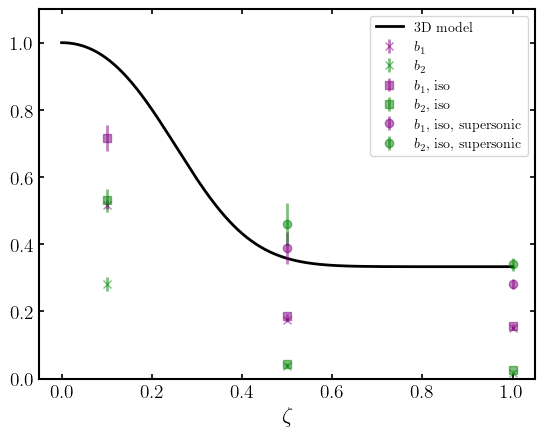

In [ ]:
zeta = np.array([0.1, 0.5, 1.0, 1.0, 0.5, 0.1])

zeta2 = np.linspace(0, 1, 1000)

b = 1/3 + 2/3 * ((1 - zeta2)**2/(1 - 2*zeta2 + 3*zeta2**2))**3
plt.plot(zeta2, b, color="black", label="3D model")
plt.errorbar(x=zeta[3:], y=data[3:, 0], yerr=data[3:, 2], fmt="x", color="purple", alpha=0.5,  label=r"$b_1$")
plt.errorbar(x=zeta[3:], y=data[3:, 1], yerr=data[3:, 3], fmt="x", color="green", alpha=0.5,  label=r"$b_2$")
plt.errorbar(x=zeta[:3], y=data[:3, 0], yerr=data[:3, 2], fmt="s", color="purple", alpha=0.5,  label=r"$b_1$, iso")
plt.errorbar(x=zeta[:3], y=data[:3, 1], yerr=data[:3, 3], fmt="s", color="green", alpha=0.5,  label=r"$b_2$, iso")
plt.errorbar(x=[0.5, 1.0], y=data_super[:, 0], yerr=data_super[:, 2], fmt="o", color="purple", alpha=0.5,  label=r"$b_1$, iso, supersonic")
plt.errorbar(x=[0.5, 1.0], y=data_super[:, 1], yerr=data_super[:, 3], fmt="o", color="green", alpha=0.5,  label=r"$b_2$, iso, supersonic")
plt.ylim(0, 1.1)
plt.legend()
plt.xlabel(r"$\zeta$")
# plt.savefig("forcing_parameter_sims.pdf")

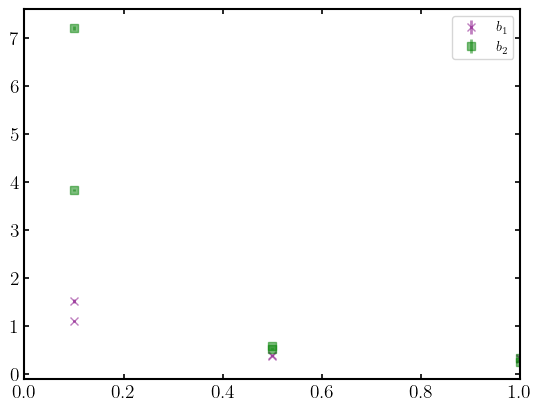

In [63]:
zeta = np.array([0.1, 0.5, 1.0, 1.0, 0.5, 0.1])

data[:, 0] = 0.3333 * data[:, 0]/data[2, 0]
data[:, 1] = 0.3333 * data[:, 1]/data[2, 1]
data[:, 2] = 0.3333 * data[:, 2]/data[2, 0]
data[:, 3] = 0.3333 * data[:, 3]/data[2, 1]

plt.errorbar(x=zeta, y=data[:, 0], yerr=data[:, 2], fmt="x", color="purple", alpha=0.5,  label=r"$b_1$")
plt.errorbar(x=zeta, y=data[:, 1], yerr=data[:, 3], fmt="s", color="green", alpha=0.5,  label=r"$b_2$")
plt.xlim(0, 1)
plt.legend()

In [64]:
data[:, 0]

array([1.52274887, 0.39408031, 0.3333    , 0.31988184, 0.373119  ,
       1.1027408 ])

In [75]:
for name in sims:
    print(name, np.mean(results[name]["mach_rms"]))

comp-iso 0.585305252468766
mix-iso 0.4276836709849872
sol-iso 0.46862739275486553
sol 0.3795572002998335
mix 0.36687283979300583
comp 0.3876845029771267


In [100]:
import numpy as np

# Parameters
N = 64
L = 1.0
dx = L / N

# Create a purely longitudinal (compressive) field in real space:
# v(x) = grad(phi), where phi is a random scalar field
phi = np.random.randn(N, N, N)
grad_phi = np.stack(np.gradient(phi, dx, axis=(0, 1, 2)), axis=-1)

# FFT of the vector field
v_k = np.fft.fftn(grad_phi, axes=(0, 1, 2))
v_k = np.fft.fftshift(v_k, axes=(0, 1, 2))

# Build k-grid
k = np.fft.fftfreq(N, d=dx)
k = np.fft.fftshift(k)
kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')
k_squared = kx**2 + ky**2 + kz**2
k_magnitude = np.sqrt(k_squared)

# Avoid division by zero
mask = k_squared > 0

kx_hat = np.zeros_like(kx)
ky_hat = np.zeros_like(ky)
kz_hat = np.zeros_like(kz)

kx_hat[mask] = kx[mask] / k_magnitude[mask]
ky_hat[mask] = ky[mask] / k_magnitude[mask]
kz_hat[mask] = kz[mask] / k_magnitude[mask]

# Dot product of v_k with k_hat
dot = (v_k[..., 0] * kx_hat +
       v_k[..., 1] * ky_hat +
       v_k[..., 2] * kz_hat)

# Longitudinal projection: dot * k̂
vL_k = np.zeros_like(v_k)
vL_k[..., 0] = dot * kx_hat
vL_k[..., 1] = dot * ky_hat
vL_k[..., 2] = dot * kz_hat

# Power calculation (exclude k=0 mode)
total_power = np.sum(np.abs(v_k[mask])**2)
longitudinal_power = np.sum(np.abs(vL_k[mask])**2)

fraction_longitudinal = longitudinal_power / total_power

print(f"Total power          : {total_power:.5e}")
print(f"Longitudinal power   : {longitudinal_power:.5e}")
print(f"Fraction longitudinal: {fraction_longitudinal:.5f}")

Total power          : 4.60715e+14
Longitudinal power   : 3.41325e+14
Fraction longitudinal: 0.74086


Text(0.5, 0, '$\\mathrm(log)(\\rho/<\\rho>)$')

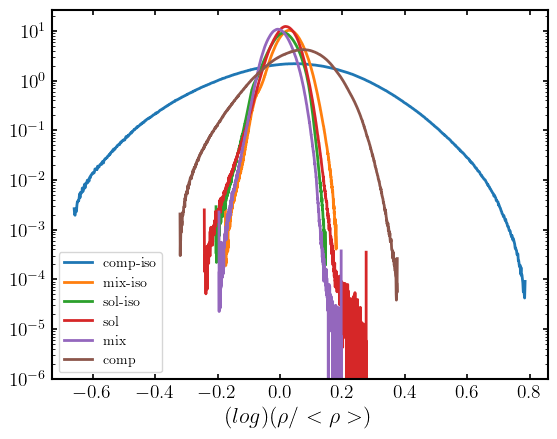

In [ ]:
fig, ax = plt.subplots()
for sim_name in sims:
    hist, bin_centers = sims[sim_name].property_pdf("Density", 350,  avg=50, hist_range=None)
    ax.plot(bin_centers, hist, label=f"{sim_name}")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel(r"$\mathrm{log}(\rho/\langle\rho\rangle)$")

In [15]:
ax.set_ylim(1e-3)
ax.set_xlabel(r"$\mathrm{log}(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Density PDF")
fig.savefig("density_pdf_allsims.pdf")

In [4]:
from numpy.fft import fftn, fftfreq, ifftn


def helmholtz_decomposition(vec_field):
    N = vec_field.shape[0]
    V_hat = np.stack([fftn(vec_field[..., i]) for i in range(3)], axis=-1)
    k = fftfreq(N) * N
    kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')
    k_squared = kx**2 + ky**2 + kz**2
    k_squared[k_squared == 0] = 1
    k_vec = np.stack((kx, ky, kz), axis=-1)
    dot = np.sum(V_hat * k_vec, axis=-1, keepdims=True)
    compressive_hat = dot * k_vec / k_squared[..., None]
    solenoidal_hat = V_hat - compressive_hat
    compressive = np.stack([np.real(ifftn(compressive_hat[..., i])) for i in range(3)], axis=-1)    
    solenoidal = np.stack([np.real(ifftn(solenoidal_hat[..., i])) for i in range(3)], axis=-1)
    return compressive, solenoidal

In [89]:
results = {sim_name: dict() for sim_name in sims}

for sim_name in results:
    results[sim_name]["mach_rms"] = np.zeros(50)
    results[sim_name]["dens_var"] = np.zeros(50)
    results[sim_name]["dens_contr_var"] = np.zeros(50)
    results[sim_name]["mean_dens"] = np.zeros(50)
    results[sim_name]["press_contr_var"] = np.zeros(50)
    results[sim_name]["comp_ratio"] = np.zeros(50)
    results[sim_name]["comp_mach_rms"] = np.zeros(50)
    results[sim_name]["dens_var_v"] = np.zeros(50)
    results[sim_name]["dens_var_m"] = np.zeros(50)
    results[sim_name]["dens_cont_var_m"] = np.zeros(50)
    results[sim_name]["dens_cont_var_v"] = np.zeros(50)


for sim_name, sim in sims.items():
    for snap in tqdm(range(350, 400), desc=f"Simulation: {sim_name}"):
        i = snap - 350
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum(data["Velocities"]**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens**2)
        dens_contrast = np.log(data["Density"]/mean_dens)
        dens_contrast_mean = np.sum(dens_contrast*vols)/np.sum(vols)
        dens_contrast_var = np.sqrt(np.sum(dens_contrast**2 * vols)/np.sum(vols) - dens_contrast_mean**2)
        mean_press = np.sum(data["Pressure"]*vols)/np.sum(vols)
        press_contrast = np.log(data["Pressure"]/mean_press)
        press_contrast_mean = np.sum(press_contrast*vols)/np.sum(vols)
        press_contrast_var = np.sqrt(np.sum(press_contrast**2 * vols)/np.sum(vols) - press_contrast_mean**2)
        results[sim_name]["mach_rms"][i] = mach_rms
        results[sim_name]["dens_var"][i] = dens_var
        results[sim_name]["mean_dens"][i] = mean_dens
        results[sim_name]["dens_contr_var"][i] = dens_contrast_var
        results[sim_name]["press_contr_var"][i] = press_contrast_var


        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(100, 100, 100))
        comp, sol = helmholtz_decomposition(grid_velocites)
        comp_ratio = np.linalg.norm(comp)/np.linalg.norm(grid_velocites)
        results[sim_name]["comp_ratio"][i] = comp_ratio
        if "iso" in sim_name:
            grid_soundspeed = 75.6
        else:
            grid_soundspeed = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], soundspeed, grid_size=(100, 100, 100))
        results[sim_name]["comp_mach_rms"][i] = np.sqrt(np.mean(np.sum(comp**2, axis=-1)/grid_soundspeed**2))

        mean_dens_v = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var_v = np.sqrt(
            np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens_v**2
        )
        dens_cont_v = np.log(data["Density"]/mean_dens_v)
        dens_cont_var_v = np.sqrt(
            np.sum(dens_cont_v**2 * vols)/np.sum(vols) - (np.sum(dens_cont_v * vols)/np.sum(vols))**2
        )

        mean_dens_m = np.sum(data["Density"]*data["Masses"])/np.sum(data["Masses"])
        dens_var_m = np.sqrt(
            np.sum(data["Density"]**2 * data["Masses"])/np.sum(data["Masses"]) - mean_dens_v**2
        )
        dens_cont_m = np.log(data["Density"]/mean_dens_m)
        dens_cont_var_m = np.sqrt(
            np.sum(dens_cont_m**2 * data["Masses"])/np.sum(data["Masses"]) - (np.sum(dens_cont_m * data["Masses"])/np.sum(data["Masses"]))**2
        )

        results[sim_name]["dens_var_v"][i] = dens_var_v
        results[sim_name]["dens_var_m"][i] = dens_cont_var_v
        results[sim_name]["dens_cont_var_v"][i] = dens_var_m
        results[sim_name]["dens_cont_var_m"][i] = dens_cont_var_m


Simulation: comp: 100%|██████████| 50/50 [04:33<00:00,  5.47s/it]


In [91]:
sims_lowres = {
    "sol-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5"),
    "comp-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5-static-comp"),
    "mix-lowres": measurments.Sim("/u/jbiba/projects/turbulent-driving/driving64-mach0.5-static-mix"),
}

results_lowres = {sim_name: dict() for sim_name in sims_lowres}

for sim_name in results_lowres:
    results_lowres[sim_name]["mach_rms"] = np.zeros(50)
    results_lowres[sim_name]["dens_var"] = np.zeros(50)
    results_lowres[sim_name]["dens_contr_var"] = np.zeros(50)
    results_lowres[sim_name]["mean_dens"] = np.zeros(50)
    results_lowres[sim_name]["press_contr_var"] = np.zeros(50)
    results_lowres[sim_name]["comp_ratio"] = np.zeros(50)
    results_lowres[sim_name]["comp_mach_rms"] = np.zeros(50)
    results_lowres[sim_name]["dens_var_v"] = np.zeros(50)
    results_lowres[sim_name]["dens_var_m"] = np.zeros(50)
    results_lowres[sim_name]["dens_cont_var_m"] = np.zeros(50)
    results_lowres[sim_name]["dens_cont_var_v"] = np.zeros(50)


for sim_name, sim in sims_lowres.items():
    for snap in tqdm(range(350, 400), desc=f"Simulation: {sim_name}"):
        i = snap - 350
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum(data["Velocities"]**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens**2)
        dens_contrast = np.log(data["Density"]/mean_dens)
        dens_contrast_mean = np.sum(dens_contrast*vols)/np.sum(vols)
        dens_contrast_var = np.sqrt(np.sum(dens_contrast**2 * vols)/np.sum(vols) - dens_contrast_mean**2)
        mean_press = np.sum(data["Pressure"]*vols)/np.sum(vols)
        press_contrast = np.log(data["Pressure"]/mean_press)
        press_contrast_mean = np.sum(press_contrast*vols)/np.sum(vols)
        press_contrast_var = np.sqrt(np.sum(press_contrast**2 * vols)/np.sum(vols) - press_contrast_mean**2)
        results_lowres[sim_name]["mach_rms"][i] = mach_rms
        results_lowres[sim_name]["dens_var"][i] = dens_var
        results_lowres[sim_name]["mean_dens"][i] = mean_dens
        results_lowres[sim_name]["dens_contr_var"][i] = dens_contrast_var
        results_lowres[sim_name]["press_contr_var"][i] = press_contrast_var


        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(100, 100, 100))
        comp, sol = helmholtz_decomposition(grid_velocites)
        comp_ratio = np.linalg.norm(comp)/np.linalg.norm(grid_velocites)
        results_lowres[sim_name]["comp_ratio"][i] = comp_ratio
        if "iso" in sim_name:
            grid_soundspeed = 75.6
        else:
            grid_soundspeed = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], soundspeed, grid_size=(100, 100, 100))
        results_lowres[sim_name]["comp_mach_rms"][i] = np.sqrt(np.mean(np.sum(comp**2, axis=-1)/grid_soundspeed**2))

        mean_dens_v = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var_v = np.sqrt(
            np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens_v**2
        )
        dens_cont_v = np.log(data["Density"]/mean_dens_v)
        dens_cont_var_v = np.sqrt(
            np.sum(dens_cont_v**2 * vols)/np.sum(vols) - (np.sum(dens_cont_v * vols)/np.sum(vols))**2
        )

        mean_dens_m = np.sum(data["Density"]*data["Masses"])/np.sum(data["Masses"])
        dens_var_m = np.sqrt(
            np.sum(data["Density"]**2 * data["Masses"])/np.sum(data["Masses"]) - mean_dens_v**2
        )
        dens_cont_m = np.log(data["Density"]/mean_dens_m)
        dens_cont_var_m = np.sqrt(
            np.sum(dens_cont_m**2 * data["Masses"])/np.sum(data["Masses"]) - (np.sum(dens_cont_m * data["Masses"])/np.sum(data["Masses"]))**2
        )

        results_lowres[sim_name]["dens_var_v"][i] = dens_var_v
        results_lowres[sim_name]["dens_var_m"][i] = dens_cont_var_v
        results_lowres[sim_name]["dens_cont_var_v"][i] = dens_var_m
        results_lowres[sim_name]["dens_cont_var_m"][i] = dens_cont_var_m



Simulation: mix-lowres: 100%|██████████| 50/50 [02:41<00:00,  3.23s/it]


In [90]:
sims_super = {
    "mix-super-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10-mix"),
    "sol-super-iso": measurments.Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10"),
}

results_super = {sim_name: dict() for sim_name in sims_super}

for sim_name in results_super:
    results_super[sim_name]["mach_rms"] = np.zeros(20)
    results_super[sim_name]["dens_var"] = np.zeros(20)
    results_super[sim_name]["dens_contr_var"] = np.zeros(20)
    results_super[sim_name]["mean_dens"] = np.zeros(20)
    results_super[sim_name]["press_contr_var"] = np.zeros(20)
    results_super[sim_name]["comp_ratio"] = np.zeros(20)
    results_super[sim_name]["comp_mach_rms"] = np.zeros(20)
    results_super[sim_name]["dens_var_v"] = np.zeros(20)
    results_super[sim_name]["dens_var_m"] = np.zeros(20)
    results_super[sim_name]["dens_cont_var_m"] = np.zeros(20)
    results_super[sim_name]["dens_cont_var_v"] = np.zeros(20)


for sim_name, sim in sims_super.items():
    for snap in tqdm(range(70, 90), desc=f"Simulation: {sim_name}"):
        i = snap - 70
        data = sim.load(snap, ["Density", "Masses", "Velocities", "Pressure", "Coordinates"])
        vols = data["Masses"]/data["Density"]
        gamma = 5/3
        if "iso" in sim_name:
            soundspeed = 75.6
        else:
            soundspeed = np.sqrt(gamma*data["Pressure"]/data["Density"])
        mach_rms = np.sqrt(np.sum(np.sum(data["Velocities"]**2, axis=1)/soundspeed**2 * vols))
        # mean_vel = np.sum(data["Velocities"]*vols[..., np.newaxis], axis=0)
        # corrected_mach_rms = np.sqrt(np.sum(np.sum((data["Velocities"] - mean_vel)**2, axis=1)/soundspeed**2 * vols))
        mean_dens = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var = np.sqrt(np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens**2)
        dens_contrast = np.log(data["Density"]/mean_dens)
        dens_contrast_mean = np.sum(dens_contrast*vols)/np.sum(vols)
        dens_contrast_var = np.sqrt(np.sum(dens_contrast**2 * vols)/np.sum(vols) - dens_contrast_mean**2)
        mean_press = np.sum(data["Pressure"]*vols)/np.sum(vols)
        press_contrast = np.log(data["Pressure"]/mean_press)
        press_contrast_mean = np.sum(press_contrast*vols)/np.sum(vols)
        press_contrast_var = np.sqrt(np.sum(press_contrast**2 * vols)/np.sum(vols) - press_contrast_mean**2)
        results_super[sim_name]["mach_rms"][i] = mach_rms
        results_super[sim_name]["dens_var"][i] = dens_var
        results_super[sim_name]["mean_dens"][i] = mean_dens
        results_super[sim_name]["dens_contr_var"][i] = dens_contrast_var
        results_super[sim_name]["press_contr_var"][i] = press_contrast_var

        grid_velocites = measurments.map_unstructured_to_structured_3d_optimized(data["Coordinates"], data["Velocities"], grid_size=(100, 100, 100))
        comp, sol = helmholtz_decomposition(grid_velocites)
        comp_ratio = np.linalg.norm(comp)/np.linalg.norm(grid_velocites)
        results_super[sim_name]["comp_ratio"][i] = comp_ratio
        results_super[sim_name]["comp_mach_rms"][i] = np.sqrt(np.mean(np.sum(comp**2, axis=-1)/soundspeed**2))

        mean_dens_v = np.sum(data["Density"]*vols)/np.sum(vols)
        dens_var_v = np.sqrt(
            np.sum(data["Density"]**2 * vols)/np.sum(vols) - mean_dens_v**2
        )
        dens_cont_v = np.log(data["Density"]/mean_dens_v)
        dens_cont_var_v = np.sqrt(
            np.sum(dens_cont_v**2 * vols)/np.sum(vols) - (np.sum(dens_cont_v * vols)/np.sum(vols))**2
        )

        mean_dens_m = np.sum(data["Density"]*data["Masses"])/np.sum(data["Masses"])
        dens_var_m = np.sqrt(
            np.sum(data["Density"]**2 * data["Masses"])/np.sum(data["Masses"]) - mean_dens_v**2
        )
        dens_cont_m = np.log(data["Density"]/mean_dens_m)
        dens_cont_var_m = np.sqrt(
            np.sum(dens_cont_m**2 * data["Masses"])/np.sum(data["Masses"]) - (np.sum(dens_cont_m * data["Masses"])/np.sum(data["Masses"]))**2
        )

        results_super[sim_name]["dens_var_v"][i] = dens_var_v
        results_super[sim_name]["dens_var_m"][i] = dens_cont_var_v
        results_super[sim_name]["dens_cont_var_v"][i] = dens_var_m
        results_super[sim_name]["dens_cont_var_m"][i] = dens_cont_var_m


Simulation: mix-super-iso:   0%|          | 0/20 [00:00<?, ?it/s]

Simulation: sol-super-iso: 100%|██████████| 20/20 [01:03<00:00,  3.20s/it]


Text(0.5, 0, '$\\zeta$')

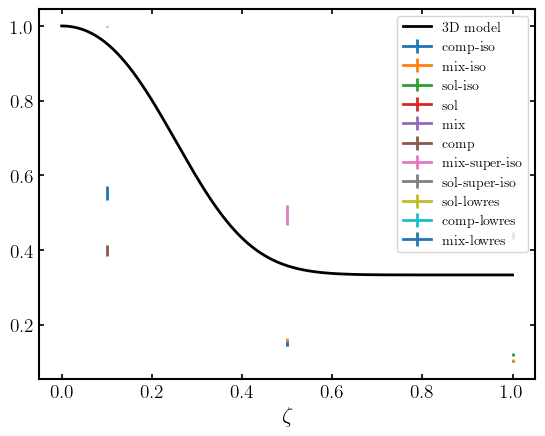

In [88]:
zeta2 = np.linspace(0, 1, 1000)

zetas = {"comp-iso": 0.1, "comp": 0.1, "mix-iso": 0.5, "mix": 0.5, "sol-iso": 1, "sol": 1, "mix-super-iso": 0.5, "sol-super-iso": 1, "sol-lowres": 1, "mix-lowres": 0.5, "comp-lowres": 0.1}

b = 1/3 + 2/3 * ((1 - zeta2)**2/(1 - 2*zeta2 + 3*zeta2**2))**3
plt.plot(zeta2, b, color="black", label="3D model")

# for sim in results:
#     val = np.mean(results[sim]["comp_ratio"])
#     b = np.mean(np.sqrt(np.exp(results[sim]["press_contr_var"]**2) - 1)/(5/3 * results[sim]["mach_rms"]**2))
#     plt.scatter([zetas[sim]], [np.sqrt(3)*val**2])
#     plt.scatter([zetas[sim]], [b], marker="x")

for sim in results:
    val = np.mean(results[sim]["comp_mach_rms"]/results[sim]["mach_rms"])
    std = np.std(results[sim]["comp_mach_rms"]/results[sim]["mach_rms"])
    plt.errorbar(x=[zetas[sim]], y=[val], yerr=[std], label=f"{sim}")

for sim in results_super:
    val = np.mean(results_super[sim]["comp_mach_rms"]/results_super[sim]["mach_rms"])
    std = np.std(results_super[sim]["comp_mach_rms"]/results_super[sim]["mach_rms"])
    plt.errorbar(x=[zetas[sim]], y=[val], yerr=[std], label=f"{sim}")

for sim in results_lowres:
    val = np.mean(results_lowres[sim]["comp_mach_rms"]/results_lowres[sim]["mach_rms"])
    std = np.std(results_lowres[sim]["comp_mach_rms"]/results_lowres[sim]["mach_rms"])
    plt.errorbar(x=[zetas[sim]], y=[val], yerr=[std], label=f"{sim}")


# plt.ylim(0, 1.1)
plt.legend()
plt.xlabel(r"$\zeta$")
# plt.savefig("forcing_parameter_sims.pdf")

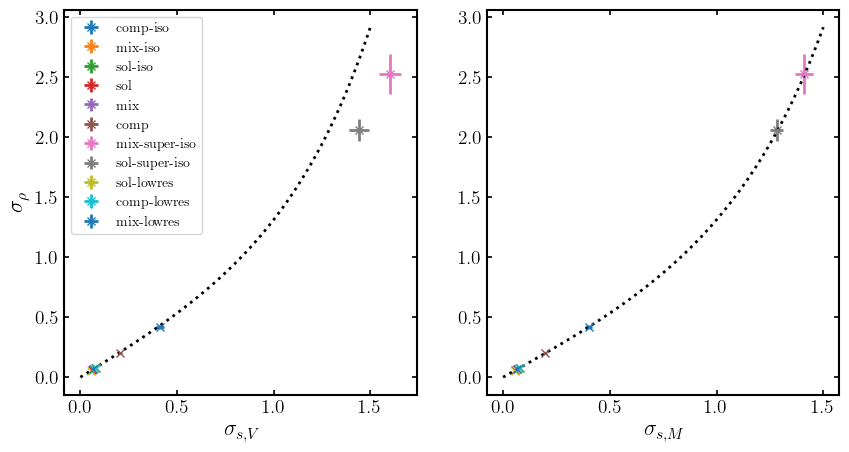

In [145]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for sim in results:
    y = np.mean(results[sim]["dens_var_v"])
    y_std = np.std(results[sim]["dens_var_v"])
    x = np.mean(results[sim]["dens_var_m"])
    x_std = np.std(results[sim]["dens_var_m"])
    x2 = np.mean(results[sim]["dens_cont_var_m"])
    x2_std = np.std(results[sim]["dens_cont_var_m"])
    axs[0].errorbar(x=[x], y=[y/1000], xerr=[x_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")
    axs[1].errorbar(x=[x2], y=[y/1000], xerr=[x2_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")


for sim in results_super:
    y = np.mean(results_super[sim]["dens_var_v"])
    y_std = np.std(results_super[sim]["dens_var_v"])
    x = np.mean(results_super[sim]["dens_var_m"])
    x_std = np.std(results_super[sim]["dens_var_m"])
    x2 = np.mean(results_super[sim]["dens_cont_var_m"])
    x2_std = np.std(results_super[sim]["dens_cont_var_m"])
    axs[0].errorbar(x=[x], y=[y/1000], xerr=[x_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")
    axs[1].errorbar(x=[x2], y=[y/1000], xerr=[x2_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")


for sim in results_lowres:
    y = np.mean(results_lowres[sim]["dens_var_v"])
    y_std = np.std(results_lowres[sim]["dens_var_v"])
    x = np.mean(results_lowres[sim]["dens_var_m"])
    x_std = np.std(results_lowres[sim]["dens_var_m"])
    x2 = np.mean(results_lowres[sim]["dens_cont_var_m"])
    x2_std = np.std(results_lowres[sim]["dens_cont_var_m"])
    axs[0].errorbar(x=[x], y=[y/1000], xerr=[x_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")
    axs[1].errorbar(x=[x2], y=[y/1000], xerr=[x2_std], yerr=[y_std/1000], label=f"{sim}", fmt="x")


axs[0].plot(np.linspace(0, 1.5, 100), np.sqrt(np.exp(np.linspace(0, 1.5, 100)**2) - 1), color="black", linestyle="dotted")
axs[1].plot(np.linspace(0, 1.5, 100), np.sqrt(np.exp(np.linspace(0, 1.5, 100)**2) - 1), color="black", linestyle="dotted")
axs[0].set_ylabel(r"$\sigma_{\rho}$")
axs[0].set_xlabel(r"$\sigma_{s, V}$")
axs[1].set_xlabel(r"$\sigma_{s, M}$")
axs[0].legend()
fig.savefig("mass_weighted_is_better.pdf")

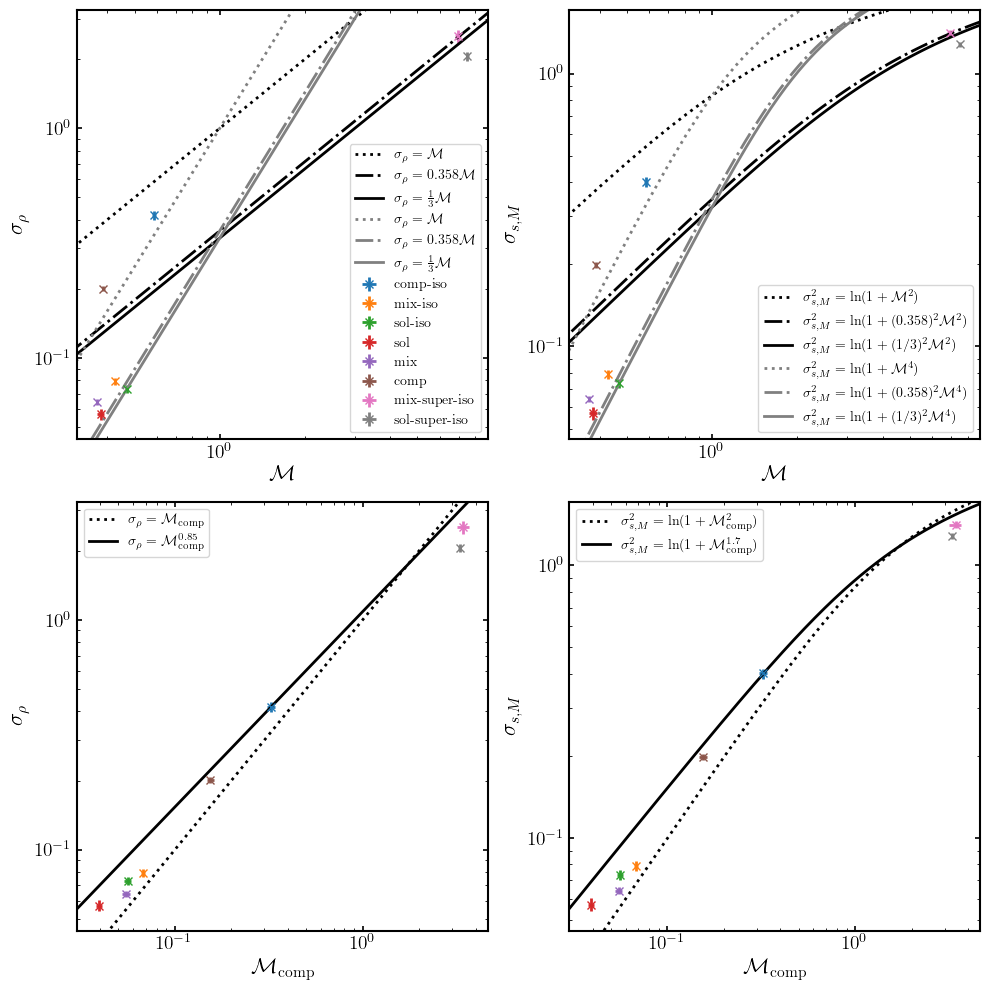

In [147]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for sim in results:
    y1 = np.mean(results[sim]["dens_var_v"])
    y1_std = np.std(results[sim]["dens_var_v"])
    x1 = np.mean(results[sim]["mach_rms"])
    x1_std = np.std(results[sim]["mach_rms"])
    
    y2 = np.mean(results[sim]["dens_cont_var_m"])
    y2_std = np.std(results[sim]["dens_cont_var_m"])

    x2 = np.mean(results[sim]["comp_mach_rms"])
    x2_std = np.std(results[sim]["comp_mach_rms"])

    axs[0, 0].errorbar(x=[x1], y=[y1/1000], xerr=[x1_std], yerr=[y1_std/1000], label=f"{sim}", fmt="x")
    axs[0, 1].errorbar(x=[x1], y=[y2], xerr=[x1_std], yerr=[y2_std], fmt="x")
    axs[1, 0].errorbar(x=[x2], y=[y1/1000], xerr=[x2_std], yerr=[y1_std/1000], fmt="x")
    axs[1, 1].errorbar(x=[x2], y=[y2], xerr=[x2_std], yerr=[y2_std], fmt="x")


for sim in results_super:
    y1 = np.mean(results_super[sim]["dens_var_v"])
    y1_std = np.std(results_super[sim]["dens_var_v"])
    x1 = np.mean(results_super[sim]["mach_rms"])
    x1_std = np.std(results_super[sim]["mach_rms"])
    
    y2 = np.mean(results_super[sim]["dens_cont_var_m"])
    y2_std = np.std(results_super[sim]["dens_cont_var_m"])

    axs[0, 0].errorbar(x=[x1], y=[y1/1000], xerr=[x1_std], yerr=[y1_std/1000], label=f"{sim}", fmt="x")
    axs[0, 1].errorbar(x=[x1], y=[y2], xerr=[x1_std], yerr=[y2_std], fmt="x")

    x2 = np.mean(results_super[sim]["comp_mach_rms"])
    x2_std = np.std(results_super[sim]["comp_mach_rms"])

    axs[1, 0].errorbar(x=[x2], y=[y1/1000], xerr=[x2_std], yerr=[y1_std/1000], fmt="x")
    axs[1, 1].errorbar(x=[x2], y=[y2], xerr=[x2_std], yerr=[y2_std], fmt="x")


# for sim in results_lowres:
#     y1 = np.mean(results_lowres[sim]["dens_var_v"])
#     y1_std = np.std(results_lowres[sim]["dens_var_v"])
#     x1 = np.mean(results_lowres[sim]["mach_rms"])
#     x1_std = np.std(results_lowres[sim]["mach_rms"])
    
#     y2 = np.mean(results_lowres[sim]["dens_cont_var_m"])
#     y2_std = np.std(results_lowres[sim]["dens_cont_var_m"])

#     axs[0, 0].errorbar(x=[x1], y=[y1/1000], xerr=[x1_std], yerr=[y1_std/1000], label=f"{sim}", fmt="x")
#     axs[0, 1].errorbar(x=[x1], y=[y2], xerr=[x1_std], yerr=[y2_std], label=f"{sim}", fmt="x")

#     x2 = np.mean(results_lowres[sim]["comp_mach_rms"])
#     x2_std = np.std(results_lowres[sim]["comp_mach_rms"])

#     axs[1, 0].errorbar(x=[x2], y=[y1/1000], xerr=[x2_std], yerr=[y1_std/1000], label=f"{sim}", fmt="x")
#     axs[1, 1].errorbar(x=[x2], y=[y2], xerr=[x2_std], yerr=[y2_std], label=f"{sim}", fmt="x")


axs[0, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[0, 0].set_xlabel(r"$\mathcal{M}$")
axs[0, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[0, 1].set_xlabel(r"$\mathcal{M}$")
axs[1, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[1, 0].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")
axs[1, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[1, 1].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")

axs[0, 0].set_xscale("log")
axs[0, 0].set_yscale("log")
axs[0, 1].set_xscale("log")
axs[0, 1].set_yscale("log")
axs[1, 1].set_xscale("log")
axs[1, 1].set_yscale("log")
axs[1, 0].set_xscale("log")
axs[1, 0].set_yscale("log")

xlim = axs[0, 0].get_xlim()
ylim = axs[0, 0].get_ylim()
axs[0, 0].plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100), color="black", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100), color="black", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100)**2, color="grey", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100)**2, color="grey", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100)**2, color="grey", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_ylim(ylim)

xlim = axs[0, 1].get_xlim()
ylim = axs[0, 1].get_ylim()
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (1)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}^2)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.358)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="dashdot", label=r"$\sigma_{s, M}^2 = \ln(1 + (0.358)^2\mathcal{M}^2)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.3333)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + (1/3)^2\mathcal{M}^2)$")

axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (1)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.358)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="dashdot", label=r"$\sigma_{s, M}^2 = \ln(1 + (0.358)^2\mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.3333)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + (1/3)^2\mathcal{M}^4)$")

axs[0, 1].set_xlim(xlim)
axs[0, 1].set_ylim(ylim)
axs[0, 1].legend()


xlim = axs[1, 0].get_xlim()
ylim = axs[1, 0].get_ylim()
axs[1, 0].plot(np.linspace(0, 10, 1000), np.linspace(0, 10, 1000), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}_{\mathrm{comp}}$")
axs[1, 0].plot(np.linspace(0, 10, 1000), 1.086 * np.linspace(0, 10, 1000)**(0.85), color="black", linestyle="-", label=r"$\sigma_{\rho} = \mathcal{M}_{\mathrm{comp}}^{0.85}$")
axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylim(ylim)
axs[1, 0].legend()

xlim = axs[1, 1].get_xlim()
ylim = axs[1, 1].get_ylim()
axs[1, 1].plot(np.linspace(0, 10, 1000), np.sqrt(np.log(1 + np.linspace(0, 10, 1000)**2)), color="black", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}_{\mathrm{comp}}^2)$")
axs[1, 1].plot(np.linspace(0, 10, 1000), np.sqrt(np.log(1 + 1.086**2 * np.linspace(0, 10, 1000)**(1.7))), color="black", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}_{\mathrm{comp}}^{1.7})$")
axs[1, 1].set_xlim(xlim)
axs[1, 1].set_ylim(ylim)
axs[1, 1].legend()

axs[0, 0].legend()
fig.tight_layout()
fig.savefig("dens_mach_relations_comp_mach.pdf")

In [137]:
zeta2 = 0
1/3 + 2/3 * ((1 - zeta2)**2/(1 - 2*zeta2 + 3*zeta2**2))**3

1.0

In [139]:
np.sqrt(3)/(np.sqrt(3)**(0.85))

np.float64(1.0858856503708696)

In [ ]:
# maybe plot for pressure dens relation?